<div style="font-family: 'Times New Roman', serif; text-align: center; padding: 20px 0;">

<hr style="border: none; border-top: 1px solid #444;">

<p style="font-size: 13px; letter-spacing: 3px; color: #666; margin: 15px 0 8px 0;">
PATCH COMPOSITION
</p>

<p style="font-size: 32px; font-weight: bold; margin: 0 0 15px 0;">
Patch - Parker Solar Probe
</p>

<hr style="border: none; border-top: 1px solid #444; width: 80%;">

</div>

In [1]:
import numpy             as np
import pandas            as pd
import speasy            as spz
import matplotlib.pyplot as plt

from matplotlib        import rcParams
from scipy.interpolate import interp1d
from scipy             import interpolate, stats
from datetime          import datetime, timedelta

from src.f_patch import average, _load_data_ephemeris_psp

In [2]:
""" Plot Config """
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 13
rcParams['axes.titlesize'] = 18
rcParams['axes.labelsize'] = 15
rcParams['xtick.labelsize'] = 13
rcParams['ytick.labelsize'] = 13
rcParams['legend.fontsize'] = 14
rcParams['figure.titlesize'] = 18

rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.25
rcParams['grid.linestyle'] = '--'
rcParams['grid.linewidth'] = 0.5

In [52]:
""" Time Config """
# start_PSP = datetime(2021, 11, 19) # Bale et al. 2023
# stop_PSP  = datetime(2021, 11, 22)

# start_PSP = datetime(2020, 6, 2) # Encounter 5
# stop_PSP  = datetime(2020, 6, 7, 12)

start_PSP = datetime(2025, 3, 18) 
stop_PSP  = datetime(2025, 3, 25)


In [54]:
""" Get Data """
Np_PSP = spz.get_data("amda/psp_spi_Hn", start_PSP, stop_PSP).to_dataframe()
Na_PSP = spz.get_data("amda/psp_spi_an", start_PSP, stop_PSP).to_dataframe()

Vp_rtn_PSP = spz.get_data("amda/psp_spi_Hv", start_PSP, stop_PSP).to_dataframe()
Va_rtn_PSP = spz.get_data("amda/psp_spi_av", start_PSP, stop_PSP).to_dataframe()

B_rtn_PSP = spz.get_data("amda/psp_b_4cyc", start_PSP, stop_PSP).to_dataframe()

psp_r_sun = spz.get_data("amda/psp_r_sun", start_PSP, stop_PSP).to_dataframe()

In [55]:
if len(Na_PSP.index) != len(Np_PSP.index):
    # Interpolate alpha density onto proton time grid
    Na_PSP = (
        Na_PSP
        .reindex(Np_PSP.index)
        .interpolate(method="time")
    )
    
    # Make sure the index is exactly the proton index
    Na_PSP.index = Np_PSP.index

In [56]:
B_rtn_PSP

,br,bt,bn
2025-03-18 00:00:00.092999936,59.284889,-24.471323,32.870869
2025-03-18 00:00:00.311000064,59.795467,-24.572929,31.915579
2025-03-18 00:00:00.529999872,59.574997,-26.312458,31.546350
2025-03-18 00:00:00.748000000,59.102844,-25.722902,31.961508
2025-03-18 00:00:00.967000064,59.515305,-23.188318,32.415833
...,...,...,...
2025-03-24 23:59:59.104000000,-284.824768,89.257431,-181.566620
2025-03-24 23:59:59.321999872,-275.216553,132.486298,-175.924698
2025-03-24 23:59:59.540000000,-278.897858,94.798203,-197.702911
2025-03-24 23:59:59.759000064,-274.920166,91.050636,-197.103928


In [57]:
# --- Components
Vp_r_PSP, Vp_t_PSP, Vp_n_PSP = Vp_rtn_PSP['vr'], Vp_rtn_PSP['vt'], Vp_rtn_PSP['vn']
Va_r_PSP, Va_t_PSP, Va_n_PSP = Va_rtn_PSP['vr'], Va_rtn_PSP['vt'], Va_rtn_PSP['vn']

B_r_PSP, B_t_PSP, B_n_PSP = B_rtn_PSP['br'], B_rtn_PSP['bt'], B_rtn_PSP['bn']

SPAN_time = Np_PSP.index
MAG_PSP_time  = B_rtn_PSP.index

In [58]:
# --- Derived parameters
alpha_abundance_PSP = (Na_PSP.iloc[:,0] / (Na_PSP.iloc[:,0] + Np_PSP.iloc[:,0])) * 100

inverse_r_PSP = 1 / psp_r_sun.iloc[:,0]

In [59]:
# --- Averaged quantities 
Vp_r_PSP_average = average(Vp_r_PSP, 10)
Va_r_PSP_average = average(Va_r_PSP, 10)

alpha_abundance_PSP_average = average(alpha_abundance_PSP, 20)

In [60]:
# --- Correlation
corr_patch_PSP = pd.Series(alpha_abundance_PSP).rolling(window=10).corr(pd.Series(Vp_r_PSP))

corr_patch_average_PSP = pd.Series(alpha_abundance_PSP_average).rolling(window=50).corr(pd.Series(Vp_r_PSP_average))

corr_patch_average_PSP_average = average(corr_patch_average_PSP, 100)

(0.03567255172534438, 0.2)

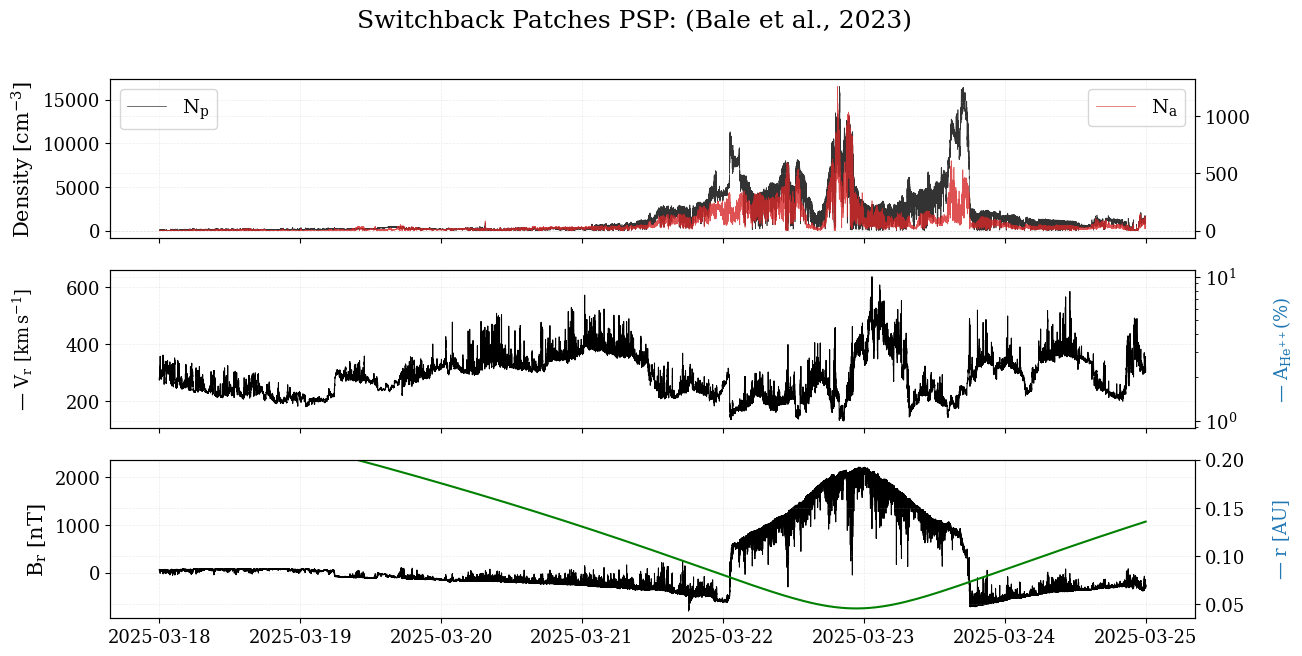

In [61]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(14,7))
fig.suptitle("Switchback Patches PSP: (Bale et al., 2023)")

plt.rcParams["mathtext.default"] = "regular"

ax1b = ax1.twinx()
ax1.plot(Np_PSP.index, Np_PSP.iloc[:,0], label='$N_p$', color='black', linewidth='0.5', alpha=0.8)
ax1b.plot(Na_PSP.index, Na_PSP.iloc[:,0], label='$N_a$', color='tab:red', linewidth='0.5', alpha=0.8)
ax1.legend(loc='upper left')
ax1b.legend(loc='upper right')
ax1.set_ylabel('Density $[cm^{-3}]$')

ax2b = ax2.twinx()
ax2.plot(Vp_r_PSP.index, Vp_r_PSP_average, label='Vp', color='black', linewidth='0.75')
# ax2b.plot(alpha_abundance_PSP.index,alpha_abundance_PSP_average,label=r'$\alpha _{\%}$',color='tab:blue',linewidth=0.75,alpha=0.8)
ax2b.set_yscale('log')
ax2.annotate(
    r'— $V_r$ $[km\,s^{-1}]$',
    xy=(-0.08, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    color='black')

ax2b.annotate(
    r'— $A_{He^{++}} (\%)$',
    xy=(1.08, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    color='tab:blue')

ax3b=ax3.twinx()
ax3.plot(MAG_PSP_time, B_r_PSP, color ='black', linewidth='0.75')
ax3b.plot(psp_r_sun.index, psp_r_sun, color='green')
ax3.set_ylabel('$B_r$ $[nT]$')
ax3b.annotate(
    r'— $r$ $[AU]$',
    xy=(1.08, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    color='tab:blue')
ax3b.set_ylim(None,0.2)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - PSP
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Angular Displacement
</p>

</div>

In [71]:
""" Ephemeris Data """
data = _load_data_ephemeris_psp(start_PSP, stop_PSP)
phi, theta, psp_r_sun = data['car_lon'], data['car_lat'], data['r_sun']

In [72]:
data

,car_lon,car_lat,r_sun
2025-03-17 23:59:59.998000128,-14.709027,3.583600,0.251621
2025-03-18 00:59:59.998000128,-15.108047,3.578771,0.250183
2025-03-18 01:59:59.998000128,-15.504843,3.573844,0.248739
2025-03-18 02:59:59.998000128,-15.899371,3.568819,0.247290
2025-03-18 03:59:59.998000128,-16.291580,3.563691,0.245836
...,...,...,...
2025-03-24 20:59:59.998000128,138.234767,0.157850,0.129949
2025-03-24 21:59:59.998000128,138.345970,0.205188,0.131934
2025-03-24 22:59:59.998000128,138.436419,0.251098,0.133908
2025-03-24 23:59:59.998000128,138.507121,0.295643,0.135872


In [73]:
t_coord = phi.index

phi_rad   = phi * np.pi/180
theta_rad = theta * np.pi/180

phi_rad_new   = phi_rad#['lon iau_sun']
theta_rad_new = theta_rad#['lat iau_sun']

t_coord_float = t_coord.astype(np.int64) / 1e9
df_time_float = Vp_rtn_PSP.index.astype(np.int64) / 1e9

interp_theta = interp1d(t_coord_float, theta_rad_new, kind='linear', bounds_error=False, fill_value="extrapolate")
interp_phi   = interp1d(t_coord_float, phi_rad_new,   kind='linear', bounds_error=False, fill_value="extrapolate")

theta_z = interp_theta(df_time_float)
phi_z   = interp_phi(df_time_float)

dtheta = np.diff(theta_z)
dphi   = np.diff(phi_z)

ds_psp    = np.sqrt(dtheta**2 + (np.cos(theta_z[:-1]) * dphi)**2)
s_psp     = np.concatenate([[0], np.cumsum(ds_psp)])
s_psp_deg = np.degrees(s_psp)

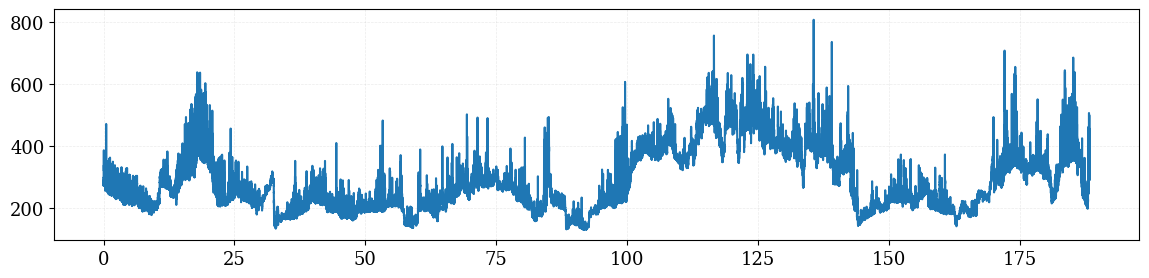

In [74]:
plt.figure(figsize=(14,3))
plt.plot(s_psp_deg, Vp_rtn_PSP['vr'])

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - PSP
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Fourier Analysis
</p>

</div>

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 0px solid #888;
">

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Velocity

In [107]:
Vp_rtn_PSP.loc[np.isnan(Vp_rtn_PSP['vr']), "vr"] = np.mean(Vp_rtn_PSP['vr'])

# --- Regular sampling ---
s_psp_new = np.linspace(0, max(s_psp_deg), int(max(s_psp_deg)/min(np.diff(s_psp_deg))))

v_r_interp = interp1d(s_psp_deg, Vp_rtn_PSP['vr'], kind='linear', bounds_error=False, fill_value="extrapolate")
v_r_new = v_r_interp(s_psp_new)

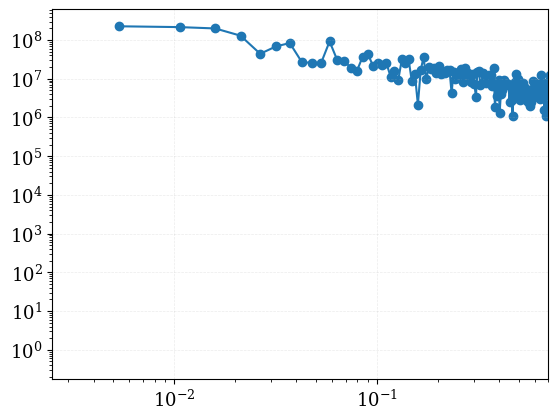

In [108]:
# --- velocity
ds_vr = np.mean(np.diff(s_psp_new))

fft_vr  = np.fft.rfft(v_r_new)
freq_vr = np.fft.rfftfreq(len(v_r_new), d=ds_vr)

plt.loglog(freq_vr[1:], np.abs(fft_vr[1:]))
plt.scatter(freq_vr[1:], np.abs(fft_vr[1:]))
# plt.axvline(1e-1, color="orange")
plt.xlim(None, 7e-1)
plt.show()

In [110]:
fft_vr[15:] = 0.0 # Bale et al. 2023
# fft_vr[14:] = 0.0 # Encounter 5

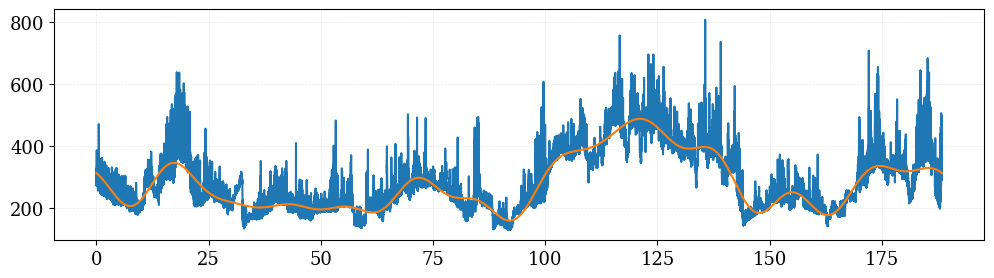

In [111]:
filter_data_vr = np.fft.irfft(fft_vr)
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(s_psp_new, v_r_new)
ax.plot(s_psp_new, filter_data_vr)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 0px solid #888;
">

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Alpha Abundance

In [113]:
alpha_percent = pd.DataFrame(alpha_abundance_PSP)
alpha_percent.columns = ["a_percent"]

In [114]:
alpha_percent.loc[np.isnan(alpha_percent['a_percent']), "a_percent"] = np.mean(alpha_percent['a_percent'])

# --- Regular sampling ---
a_percent_interp = interp1d(s_psp_deg, alpha_percent['a_percent'], kind='linear', bounds_error=False, fill_value="extrapolate")
a_percent_new = a_percent_interp(s_psp_new)

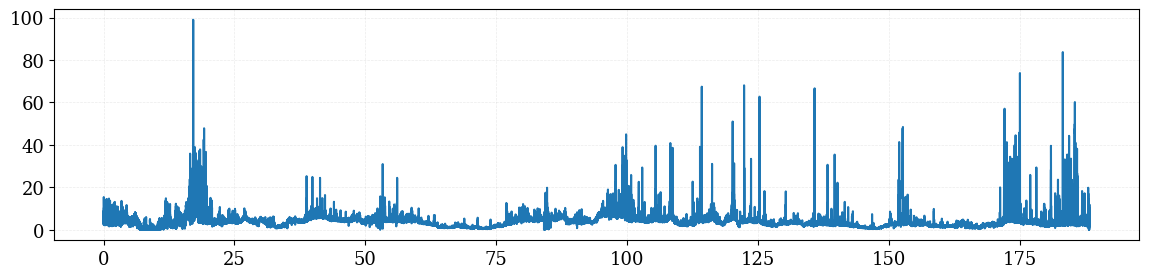

In [115]:
plt.figure(figsize=(14, 3))
plt.plot(s_psp_new, a_percent_new)

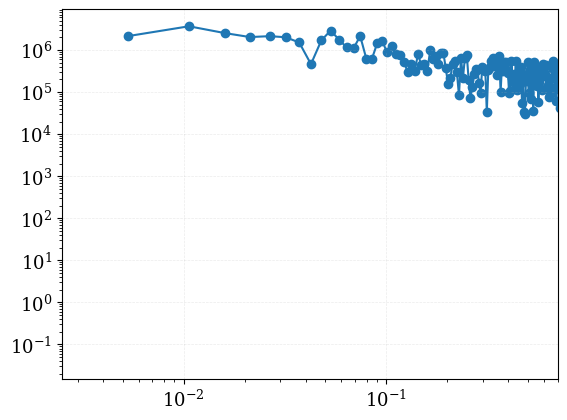

In [116]:
# --- alpha abundance
ds_a_percent = np.mean(np.diff(s_psp_new))

fft_a_percent  = np.fft.rfft(a_percent_new)
freq_a_percent = np.fft.rfftfreq(len(a_percent_new), d=ds_a_percent)

plt.loglog(freq_a_percent[1:], np.abs(fft_a_percent[1:]))
plt.scatter(freq_a_percent[1:], np.abs(fft_a_percent[1:]))
#plt.axvline(1e-1, color="orange")
plt.xlim(None, 7e-1)
plt.show()

In [117]:
fft_a_percent[15:] = 0.0

(0.0, 30.0)

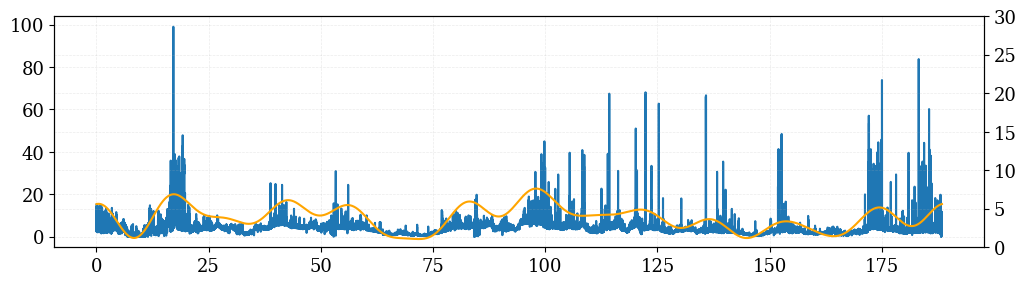

In [118]:
filter_data_a_percent = np.fft.irfft(fft_a_percent)
fig, ax = plt.subplots(figsize=(12, 3))
axb = ax.twinx()
ax.plot(s_psp_new, a_percent_new)
axb.plot(s_psp_new, filter_data_a_percent, color='orange')
axb.set_ylim(0, 30)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - PSP
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Correlation
</p>

</div>

In [122]:
r_a_vr, p_a_vr = stats.pearsonr(filter_data_vr, filter_data_a_percent)

In [123]:
r_a_vr

np.float64(0.1456022971526473)